In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [12]:
# lets prepare the data
data = load_iris()
X = data.data
y = data.target

# lets convert into dataframe
import pandas as pd
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
# preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [21]:
# lets split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# lets create the model
model = KNeighborsClassifier(n_neighbors=3,metric='cosine',n_jobs=-1)
model.fit(X_train, y_train)
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'cosine'
,metric_params,None
,n_jobs,-1


In [22]:
# lets do the prediction
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
# lets check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 1 2 2 2 0 0]
Accuracy: 0.9666666666666667


In [23]:
# lets copy the data into andother dataframe
df_test= X_test.copy()
df_test = pd.DataFrame(df_test, columns=data.feature_names)
df_test['predicted_target'] = y_pred
df_test['actual_target'] = y_test
df_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predicted_target,actual_target
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1


In [24]:
# lets pass the single value for prediction
single_value = [[5.1, 3.5, 3.4, 0.2]]
single_pred = model.predict(single_value)
print("Single value prediction:", single_pred)

# lets map 0,1,2 to actual flower names
flower_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
mapped_predictions = [flower_mapping[pred] for pred in single_pred]
print("Mapped Predictions:", mapped_predictions)

Single value prediction: [1]
Mapped Predictions: ['versicolor']


range(1, 9)


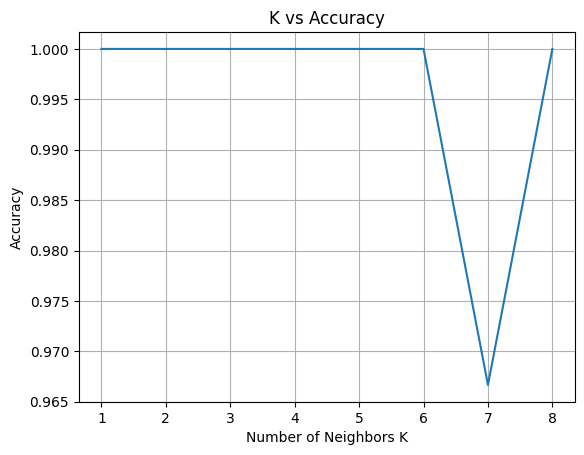

In [26]:
# lets find the k value
import matplotlib.pyplot as plt
import numpy as np

accuracy_values = []
k_values = range(1, 9)
print(k_values)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_values.append(accuracy)

plt.plot(k_values, accuracy_values)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.xticks(np.arange(1, 9, 1))
plt.grid()
plt.show()  

In [27]:
# lets we are happy with k=7
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with k=7: {accuracy}")

Accuracy with k=7: 0.9666666666666667


In [28]:
# lets save the model
import pickle
with open('knn_iris_model.pkl', 'wb') as f:
    pickle.dump(model, f)

